In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 1. Load CIFAR-100 data
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)






169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 433s 3us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


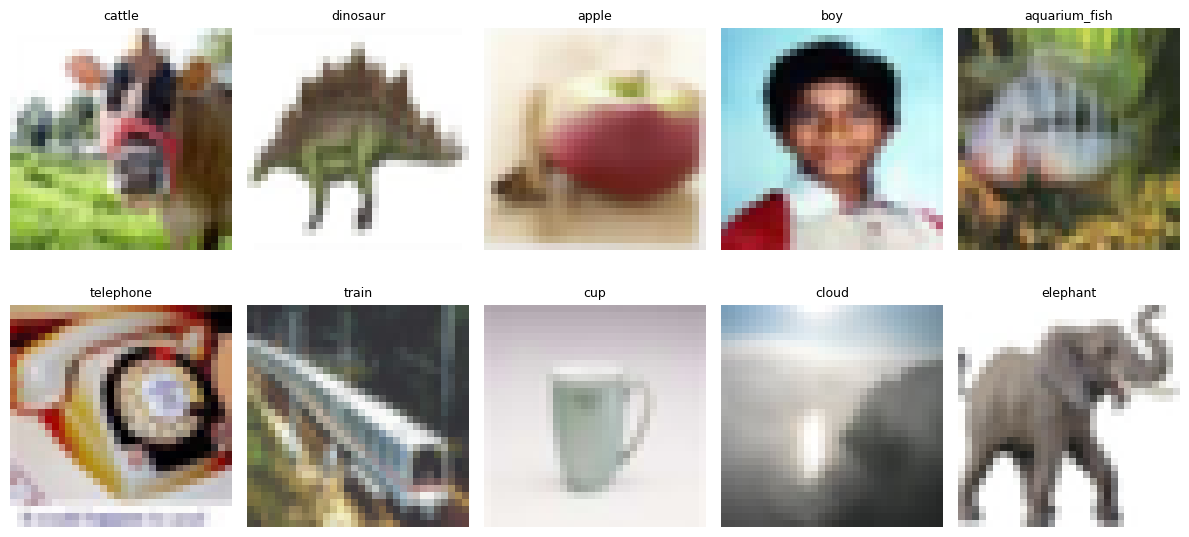

In [ ]:
# 1. Define the official 100 class names for CIFAR-100
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# 2. Plotting the first 10 items (using a 2x5 grid)
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i].flatten()[0]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values to be between 0 and 1
x_train = X_train / 255.0
x_test = X_test / 255.0

# One-hot encode targets for 100 classes
Y_train = to_categorical(y_train, 100)
Y_test = to_categorical(y_test, 100)

# 3. Build CNN Model
# Note: Increased the filter sizes and added a dense layer to accommodate 100 classes
model = Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(100, activation="softmax") # Changed output nodes to 100
])


In [ ]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# 4. Train
history = model.fit(
    x_train, Y_train,
    epochs=15, # Slightly bumped epochs since CIFAR-100 takes longer to converge
    batch_size=64,
    validation_split=0.2
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,198,756 (8.39 MB)

 Trainable params: 2,198,756 (8.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 189s 299ms/step - accuracy: 0.0846 - loss: 4.0541 - val_accuracy: 0.1863 - val_loss: 3.4825
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 185s 295ms/step - accuracy: 0.1777 - loss: 3.4429 - val_accuracy: 0.2506 - val_loss: 3.0988
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 183s 293ms/step - accuracy: 0.2267 - loss: 3.1776 - val_accuracy: 0.2866 - val_loss: 2.9380
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 212s 309ms/step - accuracy: 0.2533 - loss: 3.0149 - val_accuracy: 0.3182 - val_loss: 2.7661
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 306ms/step - accuracy: 0.2799 - loss: 2.8795 - val_accuracy: 0.3266 - val_loss: 2.7121
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 306ms/step - accuracy: 0.3022 - loss: 2.7544 - val_accuracy: 0.3391 - val_loss: 2.6305
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 291ms/step - accuracy: 0.3203 - loss: 2.6554 - val_accuracy: 0.3451 - val_loss: 2.5799
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 306ms/step - accuracy: 0.3381 -

Saving download (2).jpg to download (2).jpg


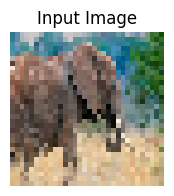

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

Predicted Item: elephant
Confidence Score: 41.72 %


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import pickle

# 1. Fetch the official CIFAR-100 fine label names
# CIFAR-100 labels are stored in binary format within the dataset package metadata
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

# To get the text names, we can extract them from the dataset cache or use this verified list:
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# 2. Trigger file upload
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# 3. Read and preprocess color image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Resize to CIFAR-100 dimensions (32x32)
img = cv2.resize(img, (32, 32))

# Normalize pixel values
img_normalized = img / 255.0

# Display the processed image
plt.figure(figsize=(2, 2))
plt.imshow(img_normalized)
plt.title("Input Image")
plt.axis('off')
plt.show()

# Reshape for the CNN structure (1 sample, 32x32 size, 3 color channels)
img_input = img_normalized.reshape(1, 32, 32, 3)

# 4. Predict
prediction = model.predict(img_input)
predicted_class_idx = np.argmax(prediction)

# 5. Output results mapped to CIFAR-100 labels
print(f"\nPredicted Item: {class_names[predicted_class_idx]}")
print(f"Confidence Score: {np.max(prediction) * 100:.2f} %")